In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,1,1,0])

In [ ]:
w=np.array([0.0,0.0])
b=0.0
lr=1
weights_history=[]
weights_history.append((w.copy(),b))
epochs=15
for epoch in range(epochs):
    errors=0
    for i in range(len(X)):
        z=np.dot(X[i],w)+b
        pred=1 if z>=0 else 0
        update=lr*(y[i]-pred)
        if update!=0:
            w=w+update*X[i]
            b=b+update
            weights_history.append((w.copy(),b))
            errors+=1
    if errors==0:
        break

In [ ]:
for idx,(w_i,b_i) in enumerate(weights_history):
    print(idx,w_i,b_i)

0 [0. 0.] 0.0
1 [0. 0.] -1.0
2 [0. 1.] 0.0
3 [-1.  0.] -1.0
4 [-1.  1.] 0.0
5 [0. 1.] 1.0
6 [-1.  0.] 0.0
7 [-1.  0.] -1.0
8 [-1.  1.] 0.0
9 [0. 1.] 1.0
10 [-1.  0.] 0.0
11 [-1.  0.] -1.0
12 [-1.  1.] 0.0
13 [0. 1.] 1.0
14 [-1.  0.] 0.0
15 [-1.  0.] -1.0
16 [-1.  1.] 0.0
17 [0. 1.] 1.0
18 [-1.  0.] 0.0
19 [-1.  0.] -1.0
20 [-1.  1.] 0.0
21 [0. 1.] 1.0
22 [-1.  0.] 0.0
23 [-1.  0.] -1.0
24 [-1.  1.] 0.0
25 [0. 1.] 1.0
26 [-1.  0.] 0.0
27 [-1.  0.] -1.0
28 [-1.  1.] 0.0
29 [0. 1.] 1.0
30 [-1.  0.] 0.0
31 [-1.  0.] -1.0
32 [-1.  1.] 0.0
33 [0. 1.] 1.0
34 [-1.  0.] 0.0
35 [-1.  0.] -1.0
36 [-1.  1.] 0.0
37 [0. 1.] 1.0
38 [-1.  0.] 0.0
39 [-1.  0.] -1.0
40 [-1.  1.] 0.0
41 [0. 1.] 1.0
42 [-1.  0.] 0.0
43 [-1.  0.] -1.0
44 [-1.  1.] 0.0
45 [0. 1.] 1.0
46 [-1.  0.] 0.0
47 [-1.  0.] -1.0
48 [-1.  1.] 0.0
49 [0. 1.] 1.0
50 [-1.  0.] 0.0
51 [-1.  0.] -1.0
52 [-1.  1.] 0.0
53 [0. 1.] 1.0
54 [-1.  0.] 0.0
55 [-1.  0.] -1.0
56 [-1.  1.] 0.0
57 [0. 1.] 1.0
58 [-1.  0.] 0.0


In [ ]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def sigmoid_deriv(a):
    return a*(1-a)

In [ ]:
np.random.seed(42)
Xm=np.array([[0,0],[0,1],[1,0],[1,1]])
ym=np.array([[0],[1],[1],[0]])
input_size=2
hidden_size=4
output_size=1
w1=np.random.randn(input_size,hidden_size)
b1=np.zeros((1,hidden_size))
w2=np.random.randn(hidden_size,output_size)
b2=np.zeros((1,output_size))
lr=0.5
epochs=10000
losses=[]

In [ ]:
for epoch in range(epochs):
    z1=np.dot(Xm,w1)+b1
    a1=sigmoid(z1)
    z2=np.dot(a1,w2)+b2
    a2=sigmoid(z2)
    loss=np.mean((ym-a2)**2)
    losses.append(loss)
    d2=(a2-ym)*sigmoid_deriv(a2)
    dw2=np.dot(a1.T,d2)
    db2=np.sum(d2,axis=0,keepdims=True)
    d1=np.dot(d2,w2.T)*sigmoid_deriv(a1)
    dw1=np.dot(Xm.T,d1)
    db1=np.sum(d1,axis=0,keepdims=True)
    w2-=lr*dw2
    b2-=lr*db2
    w1-=lr*dw1
    b1-=lr*db1

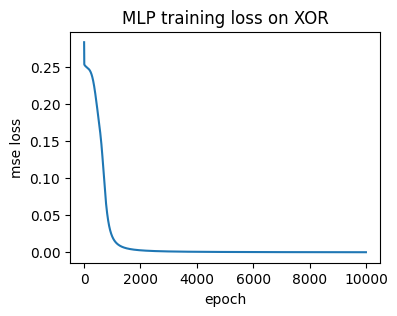

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('mse loss')
plt.title('MLP training loss on XOR')
plt.show()

In [ ]:
final_pred=a2
print(final_pred)

[[0.01005453]
 [0.98713369]
 [0.98430639]
 [0.01738976]]


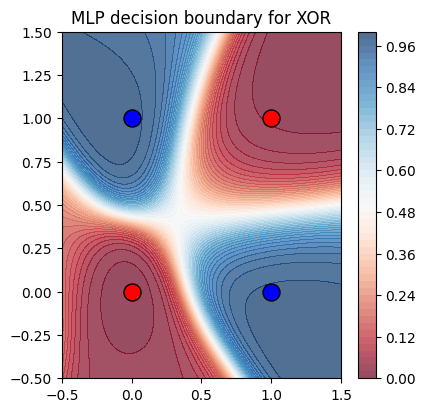

In [ ]:
xx,yy=np.meshgrid(np.linspace(-0.5,1.5,300),np.linspace(-0.5,1.5,300))
grid=np.c_[xx.ravel(),yy.ravel()]
h=sigmoid(np.dot(grid,w1)+b1)
o=sigmoid(np.dot(h,w2)+b2)
zz=o.reshape(xx.shape)
plt.figure(figsize=(4.5,4.5))
plt.contourf(xx,yy,zz,levels=50,cmap='RdBu',alpha=0.7)
plt.colorbar()
for i in range(len(Xm)):
    c='red' if ym[i][0]==0 else 'blue'
    plt.scatter(Xm[i][0],Xm[i][1],c=c,s=150,edgecolors='k')
plt.title('MLP decision boundary for XOR')
plt.show()